In [1]:
import xgi
import numpy as np
import sys
import os
# __file__ is not defined in Jupyter, use current working directory instead
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'edge_rewiring')))
from sod.simpliciality import edit_simpliciality, face_edit_simpliciality, simplicial_fraction

In [2]:
from edge_rewiring import model_generation
# print(model_generation.approximate_C_upperbound(num_node=10, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=20, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=25, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=50, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=100, min_size=2, max_size=10, num_max_hyperedge=10))
print(model_generation.approximate_C_upperbound(num_node=1500, min_size=2, max_size=7, num_max_hyperedge=10))
print(model_generation.approximate_C_upperbound(num_node=1000, min_size=2, max_size=7, num_max_hyperedge=10))
print(model_generation.approximate_C_upperbound(num_node=1000, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=10000, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=100000, min_size=2, max_size=10, num_max_hyperedge=10))
print(model_generation.possible_combinations(num_node=7, min_size=2, max_size=None))

AttributeError: module 'edge_rewiring.model_generation' has no attribute 'approximate_C_upperbound'

In [ ]:
from edge_rewiring import model_generation

H_es = model_generation.model_generation_es(es=0.3, approx_num_C=20000, num_max_hyperedge=10,num_node=100, min_size=2, max_size=7, adjust_es=False)
m = H_es.nodes.multi(['degree', 'clustering_coefficient']).asdict()
print(m)
sf = simplicial_fraction(H_es, min_size=2)
es = edit_simpliciality(H_es, min_size=2)
fes = face_edit_simpliciality(H_es, min_size=2)
print(f"Simplicial fraction: {sf}")
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")

lst = []
count = 0
for edge in H_es.edges.members():
    # print(H.edges.members())
    if (edge in lst):
        count += 1
    else:
        lst.append(edge)
print(count)


# H_sf = model_generation.model_generation_sf(sf=0.3, approx_num_E=1000, num_node=1000, min_size=2, max_size=None)
# sf = simplicial_fraction(H_sf, min_size=2)
# es = edit_simpliciality(H_sf, min_size=2)
# fes = face_edit_simpliciality(H_sf, min_size=2)
# print(f"Simplicial fraction: {sf}")
# print(f"Edit simpliciality: {es}")
# print(f"Face edit simpliciality: {fes}")

lst = []
count = 0
for edge in H_es.edges.members():
    # print(H.edges.members())
    if (edge in lst):
        count += 1
        print(edge)
    else:
        lst.append(edge)
print(count)

# Show testing method is effective
# H1 = xgi.Hypergraph()
# nodes = [i for i in range(10)]
# H1.add_nodes_from(nodes)
# H1.add_edge({1, 9})
# H1.add_edge({1, 9})
# lst = []
# count = 0
# for edge in H1.edges.members():
#     print(H1.edges.members())
#     if (edge in lst):
#         count += 1
#     else:
#         lst.append(edge)
# print(count)

❌ Warning: approx_num_C (20000) is larger than maximum possible combinations (1200)
Adjusting approx_num_C to 1200
C_distribution: [127 100 211 140 206  98 103  71  45  99]
{0: {'degree': 0, 'clustering_coefficient': 0.0}, 1: {'degree': 19, 'clustering_coefficient': 1.0}, 2: {'degree': 0, 'clustering_coefficient': 0.0}, 3: {'degree': 88, 'clustering_coefficient': 0.5757575757575758}, 4: {'degree': 18, 'clustering_coefficient': 1.0}, 5: {'degree': 0, 'clustering_coefficient': 0.0}, 6: {'degree': 18, 'clustering_coefficient': 1.0}, 7: {'degree': 0, 'clustering_coefficient': 0.0}, 8: {'degree': 0, 'clustering_coefficient': 0.0}, 9: {'degree': 18, 'clustering_coefficient': 1.0}, 10: {'degree': 24, 'clustering_coefficient': 1.0}, 11: {'degree': 0, 'clustering_coefficient': 0.0}, 12: {'degree': 22, 'clustering_coefficient': 1.0}, 13: {'degree': 0, 'clustering_coefficient': 0.0}, 14: {'degree': 0, 'clustering_coefficient': 0.0}, 15: {'degree': 63, 'clustering_coefficient': 1.0}, 16: {'degree'

In [ ]:
# Note the cmultiedge related methods in xgi are really confusing/weird. Try avoid using it.
# Below is an example of multiedge method not working
H = xgi.Hypergraph()
nodes = [i for i in range(10)]
H.add_nodes_from(nodes)
H.add_edge({1, 10})
H.add_edge({2, 10})
H.add_edge({4,8})
H.add_edge({1, 2, 10})
m = H.nodes.multi(['degree', 'clustering_coefficient'])
print(m.asdict())
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")
H.cleanup(multiedges=False)
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")
H.cleanup(singletons=True)
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")

{0: {'degree': 0, 'clustering_coefficient': 0.0}, 1: {'degree': 2, 'clustering_coefficient': 1.0}, 2: {'degree': 2, 'clustering_coefficient': 1.0}, 3: {'degree': 0, 'clustering_coefficient': 0.0}, 4: {'degree': 1, 'clustering_coefficient': 0.0}, 5: {'degree': 0, 'clustering_coefficient': 0.0}, 6: {'degree': 0, 'clustering_coefficient': 0.0}, 7: {'degree': 0, 'clustering_coefficient': 0.0}, 8: {'degree': 1, 'clustering_coefficient': 0.0}, 9: {'degree': 0, 'clustering_coefficient': 0.0}, 10: {'degree': 3, 'clustering_coefficient': 1.0}}
Edit simpliciality: 0.8
Face edit simpliciality: 0.6666666666666666
Edit simpliciality: 0.75
Face edit simpliciality: 0.6666666666666666
Edit simpliciality: 0.75
Face edit simpliciality: 0.6666666666666666


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,8) # make figures big for easier viewing 
                                        #    (width, height in inches)
# Experiment to find the relationship between edit simpliciality and face edit simpliciality
# for a range of edit simpliciality values
es = []
fes = []
float_range = np.arange(0, 1, 0.02)
for i in range(len(float_range)):
	H = model_generation.edge_rewire_model(edit_simpliciality=float_range[i], approx_num_C=5000, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=None)
	es.append(edit_simpliciality(H, min_size=2))
	fes.append(face_edit_simpliciality(H, min_size=2))
fig, ax = plt.subplots()
ax.plot(es, fes, color='red')

### DO THIS: Add the line of code to plot the trajectory here

ax.set_xlabel('es')
ax.set_ylabel('fes')
# An example of implicit line continuation. Python knows to keep on reading to
#    the next line because the set of parentheses hasn't been closed by the end
#    of the first line.
ax.set_title("velocity vs mass".
             format(es, fes))
plt.show()


AttributeError: module 'edge_rewiring.model_generation' has no attribute 'edge_rewire_model'

In [ ]:
node = []
cc = []
# Experiment to find the relationship between edit simpliciality and clustering coefficient
fig, ax = plt.subplots()
for i in range(10):
    H = model_generation.edge_rewire_model(0.5, approx_num_C=50, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=None)
    community_clustering = xgi.spectral_clustering(H)
    print(community_clustering)
# 	for idx in range(len(clustering_coefficient)):
# 		node.append(idx)
# 		cc.append(clustering_coefficient[idx])
# ax.scatter(node, cc, color='red')
     



# ### DO THIS: Add the line of code to plot the trajectory here

# ax.set_xlabel('node')
# ax.set_ylabel('cc')
# # An example of implicit line continuation. Python knows to keep on reading to
# #    the next line because the set of parentheses hasn't been closed by the end
# #    of the first line.
# ax.set_title("node vs cc".
#              format(node, cc))
# plt.show()

In [ ]:
from edge_rewiring import model_exper

model_exper.test_powerlaw_on_generated_model(es=.5, approx_num_C=1600, num_max_hyperedge=10, num_node=2000, runs=20)

Testing power-law for model: es=0.5, C≈1600, max_edges=10, nodes=2000
Calculating best minimal value for power law fit
  R = 3.7245, p = 0.0001
Calculating best minimal value for power law fit
  R = 0.5097, p = 0.0145
Calculating best minimal value for power law fit
  R = 0.0000, p = 1.0000


Less than 2 unique data values left after xmin and xmax options! Cannot fit. Returning nans.
/Users/ournengtieng/the-simpliciality-of-higher-order-networks-3/.venv/lib/python3.13/site-packages/powerlaw.py:1383: RuntimeWarning: invalid value encountered in scalar divide
  alpha = 1 + len(data)/sum( log( data / (self.xmin) ))
/Users/ournengtieng/the-simpliciality-of-higher-order-networks-3/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ournengtieng/the-simpliciality-of-higher-order-networks-3/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
No valid fits found.
Not enough data. Returning nan
No valid fits found.
Not enough data. Returning nan


Calculating best minimal value for power law fit
  R = -0.0041, p = 0.9143
Calculating best minimal value for power law fit
  R = 0.9406, p = 0.0010
Calculating best minimal value for power law fit
  R = 1.2774, p = 0.0000
Calculating best minimal value for power law fit
  R = 0.6169, p = 0.0170
Calculating best minimal value for power law fit
  R = 1.0861, p = 0.0001
Calculating best minimal value for power law fit
  R = 1.8014, p = 0.0126
Calculating best minimal value for power law fit
  R = -0.0041, p = 0.7213
Calculating best minimal value for power law fit
  R = 1.1047, p = 0.0009
Calculating best minimal value for power law fit
  R = 1.1728, p = 0.0041
Calculating best minimal value for power law fit
  R = 1.3263, p = 0.0043
Calculating best minimal value for power law fit
  R = 1.7929, p = 0.0118
Calculating best minimal value for power law fit
  R = 0.2275, p = 0.5426
Calculating best minimal value for power law fit
  R = 1.1403, p = 0.0009
Calculating best minimal value for p

approx_C=100, actual_es=0.4957
approx_C=200, actual_es=0.5000
approx_C=300, actual_es=0.5011
approx_C=400, actual_es=0.5008
approx_C=500, actual_es=0.5006
approx_C=600, actual_es=0.5005
approx_C=700, actual_es=0.5000
approx_C=800, actual_es=0.5004
approx_C=900, actual_es=0.5004
approx_C=1000, actual_es=0.5000
approx_C=1100, actual_es=0.5000
approx_C=1200, actual_es=0.5000
approx_C=1300, actual_es=0.5003
approx_C=1400, actual_es=0.5002
approx_C=1500, actual_es=0.5000
approx_C=1600, actual_es=0.5000
approx_C=1700, actual_es=0.5002
approx_C=1800, actual_es=0.5002
approx_C=1900, actual_es=0.5000


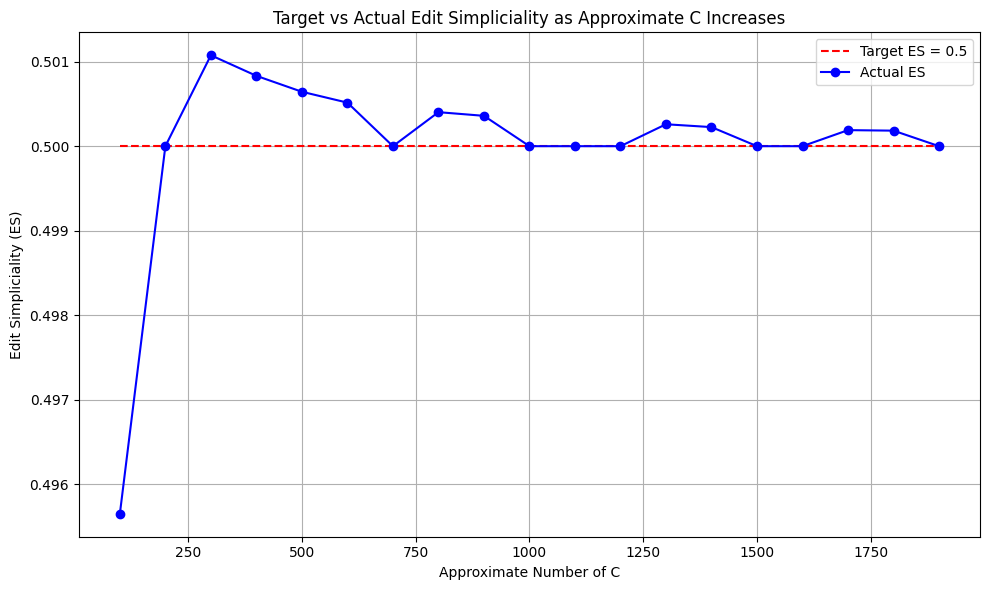

In [ ]:
# Testing approx_C
import matplotlib.pyplot as plt
from sod import edit_simpliciality
from edge_rewiring import model_generation

target_es = 0.5
approx_C_values = list(range(100, 2000, 100))
actual_es_values = []

for approx_C in approx_C_values:
    H = model_generation.model_generation_es(
        es=target_es,
        approx_num_C=approx_C,
        num_max_hyperedge=30,  
        num_node=100,
        min_size=2,
        max_size=None
    )
    actual_es = edit_simpliciality(H, min_size=2)
    actual_es_values.append(actual_es)
    print(f"approx_C={approx_C}, actual_es={actual_es:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(approx_C_values, [target_es]*len(approx_C_values), 'r--', label=f"Target ES = {target_es}")
plt.plot(approx_C_values, actual_es_values, 'bo-', label="Actual ES")
plt.xlabel("Approximate Number of C")
plt.ylabel("Edit Simpliciality (ES)")
plt.title("Target vs Actual Edit Simpliciality as Approximate C Increases")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Testing num_max_hyperedge
import matplotlib.pyplot as plt
from sod import edit_simpliciality
from edge_rewiring import model_generation

target_es = 0.5
num_hyperedge = list(range(100, 2000, 100))
actual_es_values = []

for approx_C in approx_C_values:
    H = model_generation.model_generation_es(
        es=target_es,
        approx_num_C=700,
        num_max_hyperedge=num_hyperedge,  
        num_node=100,
        min_size=2,
        max_size=None
    )
    actual_es = edit_simpliciality(H, min_size=2)
    actual_es_values.append(actual_es)
    print(f"approx_C={approx_C}, actual_es={actual_es:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(approx_C_values, [target_es]*len(approx_C_values), 'r--', label=f"Target ES = {target_es}")
plt.plot(approx_C_values, actual_es_values, 'bo-', label="Actual ES")
plt.xlabel("Approximate Number of C")
plt.ylabel("Edit Simpliciality (ES)")
plt.title("Target vs Actual Edit Simpliciality as Approximate C Increases")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print(es)
print(fes)